In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

# 1 Conv Block Module with experiments

### Import Library
- torch
- datasets, transforms
- dataloader

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## Load data for train, test and val split

Tran dataset will be using some augmentations.

In [3]:
transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])

train_data_set = datasets.ImageFolder("../datasets/final_dataset/train", transform=transform)
val_data_set = datasets.ImageFolder("../datasets/final_dataset/val", transform=transform)

train = DataLoader(
    train_data_set, 
    batch_size=32, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
    shuffle=True
    )

val = DataLoader(
    val_data_set,
    batch_size=32, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
)

## Train the model

### Load modules and architecture
* Trainer,
* Architecture

In [4]:
from modules.helper.trainer import  Trainer
from modules.architectures.Architecture import Architecture
from modules.helper.charts import gen_line_charts

In [5]:
def find_best_models(df):
    best = df[df["val_accuracy"] == df["val_accuracy"].max()] # combines and remove duplicates
    return best

### Load and Construct a architecture

In [6]:
torch.manual_seed(41)
model = Architecture()

model.add(
    # first layer
    nn.Conv2d(3, 8, 3, 1, 1),
    nn.BatchNorm2d(8),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    
    # second Layer
    nn.Conv2d(8, 16, 3, 1, 1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2, 2)
)

Architecture(
  (layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
)

In [7]:
params = 1440
channels = 16
size = 112//2//2

print(f"Total Convolutional Parameters: {params}")
print(f"Final Convolutional Out Channels: {channels}")
print(f"Final Convolutional Size: {size}")

Total Convolutional Parameters: 1440
Final Convolutional Out Channels: 16
Final Convolutional Size: 28


In [8]:
flatten_size = channels * size * size

l1_param = flatten_size * channels + channels

l2_param = channels * 36 + 36

total_params = params + l1_param + l2_param

model.add(
    nn.Flatten(),
    nn.Linear(flatten_size, channels),
    nn.ReLU(),
    nn.Linear(channels, 36)
)

print(f"TOTAL TRAINABLE PARAMETERS = {total_params}")

TOTAL TRAINABLE PARAMETERS = 202772


In [9]:
path = "../documentations/experiments/tika-2cnn-no-aug"

# Using Trainer to train the model
trainer = Trainer(
    model,
    train,
    val,
    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=2e-3,
        momentum=0.9,
        weight_decay=3e-5,
    ),
    device="cuda",
    criterion = nn.CrossEntropyLoss()
)

# this is metrics
metrics = trainer.fit(30, path, 1);

EPOCH 5 completed | Training Loss = 0.19767731842275033 | Validation Loss = 0.26782772919620673
EPOCH 10 completed | Training Loss = 0.07766807923002599 | Validation Loss = 0.11329053670384738
EPOCH 15 completed | Training Loss = 0.03185528022656939 | Validation Loss = 0.14076944398960778
EPOCH 20 completed | Training Loss = 0.017332253102843507 | Validation Loss = 0.0920534480699828
EPOCH 25 completed | Training Loss = 0.005170768652067358 | Validation Loss = 0.07106892353467306
EPOCH 30 completed | Training Loss = 0.02684222140422194 | Validation Loss = 0.10683210032039991


## Model with highest Accuracy

In [10]:
find_best_models(metrics)

,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
26,27,0.004646,0.065403,0.998917,0.998918,0.998917,0.998917,0.985463,0.985681,0.985463,0.985473


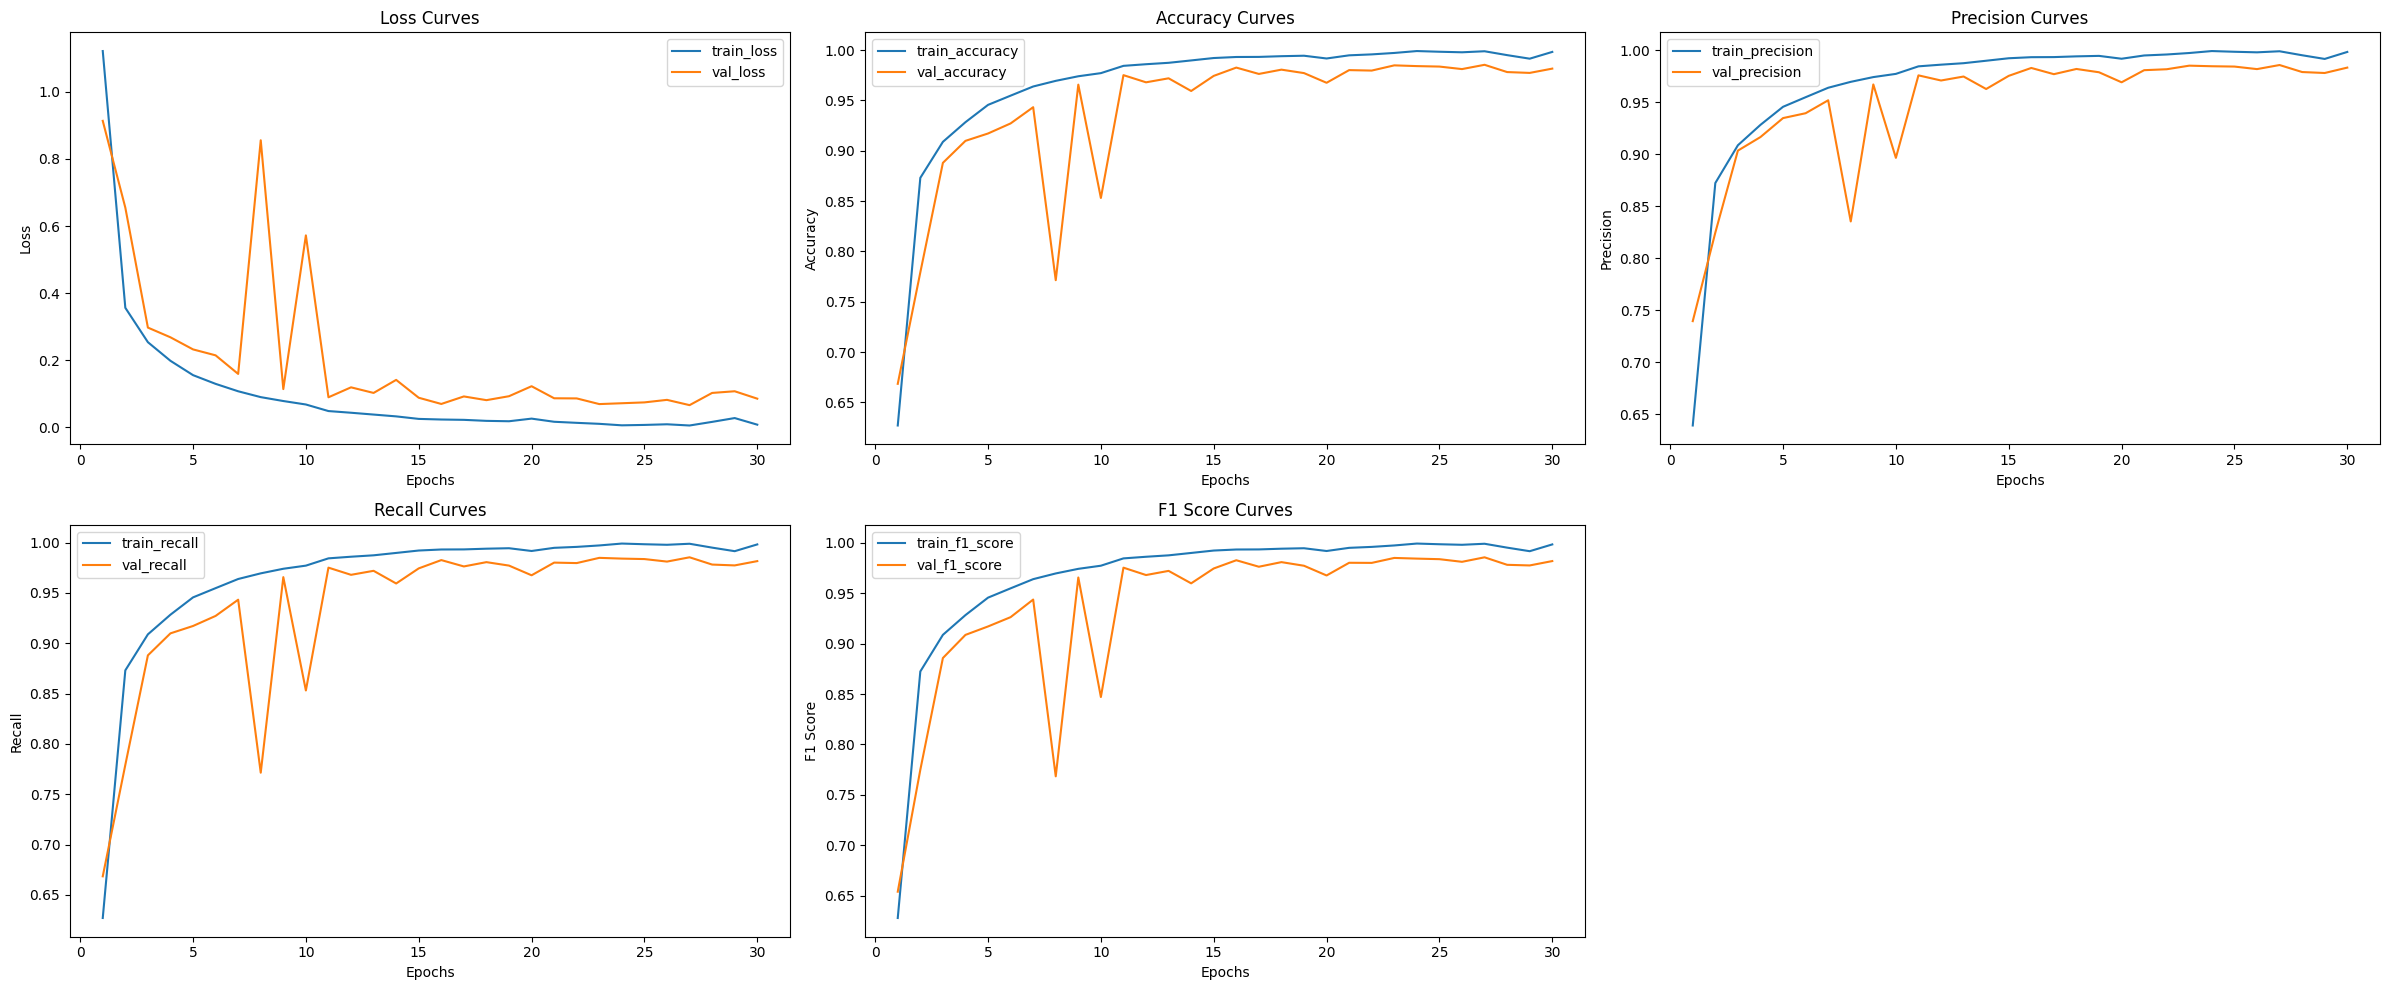

In [11]:
gen_line_charts(metrics, path, "training_metrics_graph.png", ["train_", "val_"])